# Jobsheet 05: Mengukur Kemiripan Citra dan Penerapannya dalam Pengenalan Pola

# Praktikum 1: Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

## Tujuan
Praktikum ini bertujuan menghitung dan membandingkan dua metode pengukuran jarak
berbasis piksel antara patch-patch citra, yaitu:

- **Jarak Euclidean (L2):** Akar dari jumlah kuadrat perbedaan nilai piksel.
  Sensitif terhadap perbedaan besar pada piksel tertentu.
- **Jarak Manhattan (L1):** Jumlah nilai absolut perbedaan piksel.
  Lebih robust terhadap outlier dibanding L2.

## Konsep Patch
Patch adalah potongan kecil dari sebuah citra. Dengan mem-*flatten* patch menjadi
vektor 1D, kita bisa menghitung jarak antar patch seperti menghitung jarak antar
dua titik dalam ruang berdimensi tinggi.

## Skenario Pengujian
| Perbandingan | Ekspektasi |
|---|---|
| Patch 1 vs Patch 2 | Jarak **besar** (lokasi berbeda, konten berbeda) |
| Patch 1 vs Patch 3 | Jarak **kecil** (Patch 3 = Patch 1 + sedikit noise) |

## Library yang Digunakan
- `numpy` — manipulasi array
- `scipy.spatial.distance` — perhitungan jarak L1 dan L2
- `scikit-image` — memuat citra dan konversi format
- `matplotlib` — visualisasi patch

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


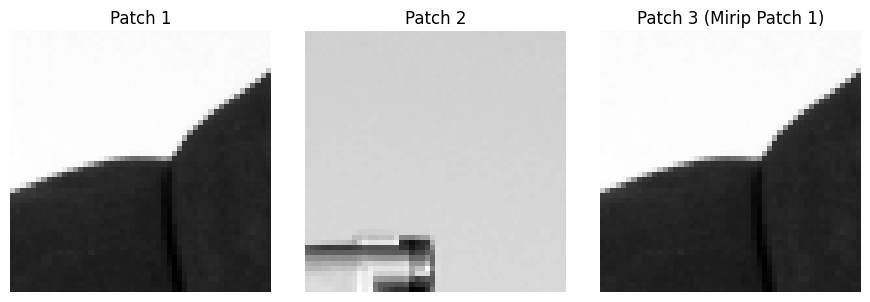

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = patch1 + 0.1             # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1)    # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Kesimpulan Praktikum 1

Dari hasil praktikum ini dapat disimpulkan:

1. **Jarak Patch 1 vs Patch 2** (lokasi berbeda) menghasilkan nilai yang **lebih besar**
   dibanding Patch 1 vs Patch 3, karena konten visual kedua patch memang berbeda.

2. **Jarak Patch 1 vs Patch 3** menghasilkan nilai yang **kecil** karena Patch 3 hanyalah
   Patch 1 yang ditambahkan offset intensitas kecil (+0.1), sehingga pola pikselnya
   hampir identik.

3. **Perbandingan L1 vs L2:**
   - Nilai L1 (Manhattan) selalu **lebih besar** dari L2 (Euclidean) karena L1 menjumlahkan
     perbedaan absolut tanpa dikuadratkan
   - L2 lebih sensitif terhadap perbedaan besar pada piksel tertentu
   - Keduanya menunjukkan **tren yang sama** — jarak kecil untuk patch mirip,
     jarak besar untuk patch berbeda

4. Metrik berbasis piksel ini sederhana namun **sensitif terhadap perubahan pencahayaan
   global** — terbukti Patch 3 tetap memiliki jarak kecil meski seluruh intensitasnya
   digeser secara merata.

# Praktikum 2: Menghitung Cosine Similarity antara Histogram Warna

## Tujuan
Praktikum ini menghitung kemiripan antara citra berwarna berdasarkan **histogram warna**
menggunakan metode **Cosine Similarity**.

## Konsep Utama
- **Histogram Warna:** Representasi distribusi warna dalam citra. Setiap citra direpresentasikan
  sebagai vektor fitur yang menggabungkan histogram channel R, G, dan B.
- **Cosine Similarity:** Mengukur kosinus sudut antara dua vektor fitur. Nilainya berkisar
  antara 0 hingga 1:
  - Nilai **mendekati 1** → dua citra sangat mirip distribusi warnanya
  - Nilai **mendekati 0** → dua citra sangat berbeda distribusi warnanya

> **Catatan:** `scipy.spatial.distance.cosine` menghitung **jarak cosine** (1 - similarity),
> sehingga kita perlu menguranginya dari 1 untuk mendapatkan **cosine similarity**.

## Skenario Pengujian
| Perbandingan | Ekspektasi |
|---|---|
| Image 1 (Astronaut) vs Image 2 (Coffee) | Similarity **rendah** (citra berbeda) |
| Image 1 (Astronaut) vs Image 3 (Astronaut) | Similarity **= 1.0** (citra identik) |
| Image 1 (Astronaut) vs Image 4 (Downsampled) | Similarity **sangat tinggi** (konten sama) |

## Library yang Digunakan
- `numpy` — manipulasi array dan histogram
- `scipy.spatial.distance` — perhitungan cosine distance
- `scikit-image` — memuat citra
- `matplotlib` — visualisasi

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee)            : 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut)         : 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled)       : 1.0000


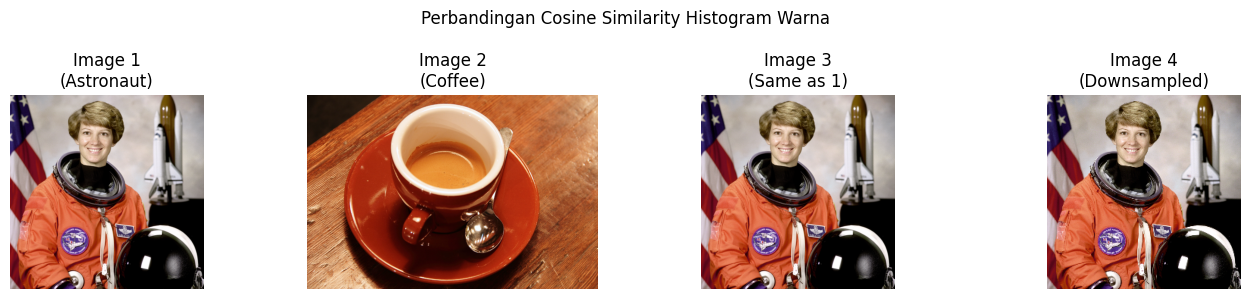

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()           # Citra yang berbeda
    image3 = data.astronaut()        # Citra yang sama (untuk perbandingan)
    image4 = image1[::2, ::2, :]    # Versi downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee)            : {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut)         : {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled)       : {sim_14:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1\n(Astronaut)'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2\n(Coffee)'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3\n(Same as 1)'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4\n(Downsampled)'); axes[3].axis('off')
plt.suptitle('Perbandingan Cosine Similarity Histogram Warna', fontsize=12)
plt.tight_layout()
plt.show()

## Kesimpulan Praktikum 2

Dari hasil praktikum ini dapat disimpulkan:

1. **Image 1 vs Image 3 (identik)** menghasilkan Cosine Similarity = **1.0000** karena
   kedua histogram warnanya benar-benar sama persis — ini membuktikan metode bekerja
   dengan benar.

2. **Image 1 vs Image 2 (berbeda)** menghasilkan nilai similarity yang **rendah** karena
   distribusi warna astronaut (dominan biru, oranye) sangat berbeda dari citra coffee
   (dominan coklat, krem).

3. **Image 1 vs Image 4 (downsampled)** menghasilkan similarity yang **sangat tinggi
   (mendekati 1.0)** meskipun ukuran citra berbeda. Ini menunjukkan bahwa histogram
   warna yang dinormalisasi **tidak sensitif terhadap perubahan resolusi** — distribusi
   warna tetap sama meski jumlah piksel berkurang.

4. **Keunggulan Cosine Similarity berbasis histogram:**
   - Tidak terpengaruh ukuran/resolusi citra (karena dinormalisasi)
   - Cepat dihitung dan efisien sebagai fitur ringkasan citra

5. **Keterbatasan:** Histogram warna tidak mempertimbangkan **posisi spasial** piksel —
   dua citra dengan warna yang sama namun susunan berbeda bisa dianggap sangat mirip.

# Praktikum 3: Menghitung Structural Similarity Index (SSIM)

## Tujuan
Praktikum ini mengukur kemiripan struktural antara dua citra menggunakan **SSIM**,
sebuah metrik yang dirancang agar lebih sesuai dengan persepsi visual manusia
dibanding metrik berbasis piksel sederhana seperti MSE.

## Konsep Utama
SSIM membandingkan tiga komponen secara bersamaan:

| Komponen | Cara Ukur | Pertanyaan |
|---|---|---|
| **Luminansi** | Rata-rata (mean) piksel | Apakah keduanya sama-sama terang? |
| **Kontras** | Standar deviasi piksel | Apakah variasi intensitasnya sama? |
| **Struktur** | Korelasi antar piksel | Apakah pola/teksturnya mirip? |

Nilai SSIM berkisar **-1 hingga 1**:
- **1.0** → identik sempurna
- **0.0** → tidak ada kemiripan struktural
- **< 0** → sangat tidak mirip

## Skenario Pengujian
| Versi Citra | Distorsi | Ekspektasi SSIM |
|---|---|---|
| Same | Tidak ada | **1.0000** |
| Noisy | Noise Gaussian | Agak rendah |
| Contrast | Intensitas dikali 0.8 | Sedang (struktur sama, luminansi beda) |
| Blurred | Gaussian blur σ=1.5 | Agak rendah (struktur melunak) |

## Library yang Digunakan
- `scikit-image` — memuat citra, SSIM, noise, dan blur
- `numpy` — manipulasi array
- `matplotlib` — visualisasi hasil dan peta perbedaan SSIM

SSIM (Ref vs Same)    : 1.0000
SSIM (Ref vs Noisy)   : 0.2954
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred) : 0.8027


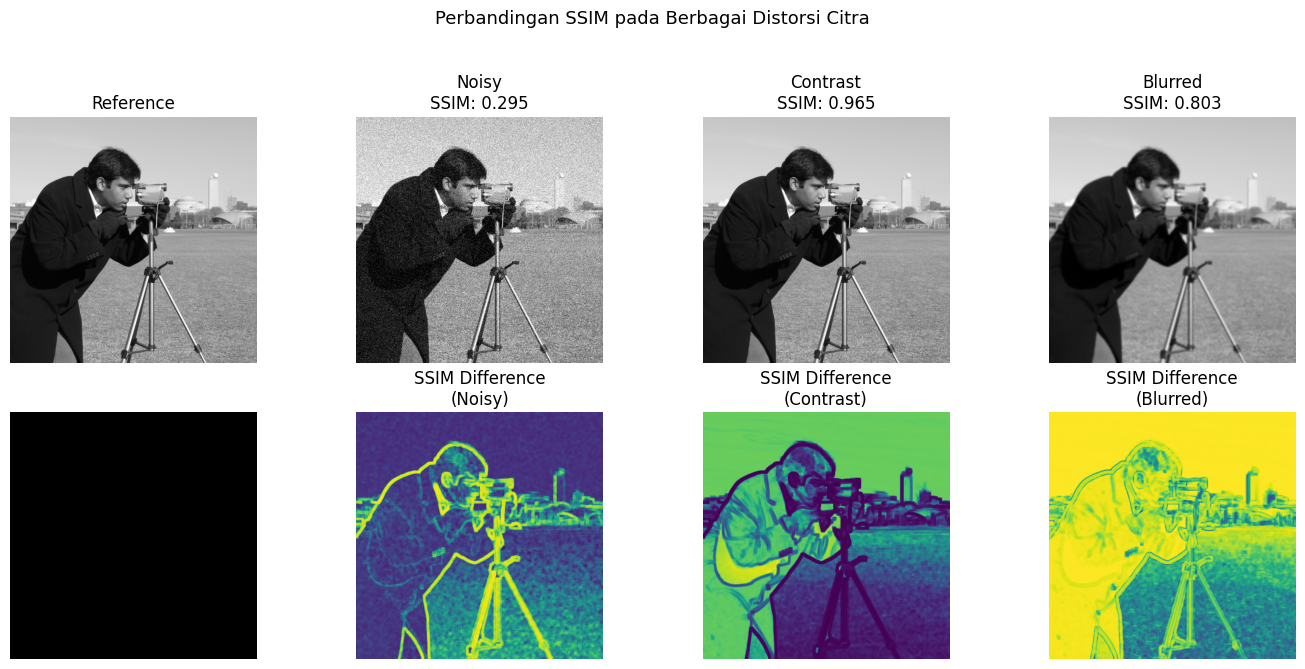

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()
# b) Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
# c) Citra dengan kontras berbeda
image_contrast = np.clip(image_ref * 0.8, 0, 1)
# d) Citra yang di-blur
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
data_range = image_ref.max() - image_ref.min()

ssim_same,     _            = ssim(image_ref, image_same,     data_range=data_range, full=True)
ssim_noisy,    diff_noisy   = ssim(image_ref, image_noisy,    data_range=data_range, full=True)
ssim_contrast, diff_contrast= ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred,  diff_blurred = ssim(image_ref, image_blurred,  data_range=data_range, full=True)

# 4. Tampilkan hasil SSIM
print(f"SSIM (Ref vs Same)    : {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy)   : {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred) : {ssim_blurred:.4f}")

# 5. Visualisasi citra dan peta perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
ax = axes.ravel()

ax[0].imshow(image_ref,      cmap='gray'); ax[0].set_title('Reference');                        ax[0].axis('off')
ax[1].imshow(image_noisy,    cmap='gray'); ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}');   ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred,  cmap='gray'); ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}');  ax[3].axis('off')

# Baris bawah: peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray'); ax[4].set_title(''); ax[4].axis('off')  # Placeholder
ax[5].imshow(diff_noisy,    cmap='viridis'); ax[5].set_title('SSIM Difference\n(Noisy)');    ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Difference\n(Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred,  cmap='viridis'); ax[7].set_title('SSIM Difference\n(Blurred)');  ax[7].axis('off')

plt.suptitle('Perbandingan SSIM pada Berbagai Distorsi Citra', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Kesimpulan Praktikum 3

Dari hasil praktikum ini dapat disimpulkan:

1. **Ref vs Same → SSIM = 1.0000** — terbukti bahwa citra yang identik menghasilkan
   skor sempurna, memvalidasi bahwa implementasi SSIM berjalan benar.

2. **Ref vs Noisy** menghasilkan SSIM yang **paling rendah** di antara semua distorsi.
   Noise Gaussian mengacak nilai piksel secara acak sehingga merusak ketiga komponen
   SSIM (luminansi, kontras, dan struktur) sekaligus. Peta perbedaan SSIM terlihat
   berbintik merata di seluruh citra.

3. **Ref vs Contrast** menghasilkan SSIM yang **sedang**. Pengurangan kontras (×0.8)
   mengubah luminansi dan kontras namun **tidak merusak struktur** — tepi dan pola
   tetap ada di posisi yang sama. Ini menunjukkan SSIM lebih toleran terhadap
   perubahan kecerahan global dibanding noise acak.

4. **Ref vs Blurred** menghasilkan SSIM yang **relatif tinggi** karena blur Gaussian
   tidak menambahkan informasi acak — hanya memperhalus tepi. Struktur objek masih
   dapat dikenali. Peta perbedaan SSIM paling terlihat di area tepi/detail tajam.

5. **Peta perbedaan SSIM** sangat berguna untuk mengidentifikasi **lokasi distorsi**
   dalam citra — area gelap pada peta = kemiripan tinggi, area terang = ketidakmiripan
   struktural tinggi.

6. SSIM terbukti lebih sesuai persepsi manusia dibanding metrik piksel biasa:
   blur yang "masih bisa dilihat" mendapat skor lebih tinggi dari noise acak yang
   secara visual lebih mengganggu.

# Praktikum 4: Penerapan Template Matching

## Tujuan
Praktikum ini menerapkan teknik **Template Matching** untuk menemukan lokasi suatu
objek kecil (template) di dalam citra yang lebih besar secara otomatis.

## Konsep Utama
- **Template:** Potongan kecil citra yang menjadi "objek yang dicari"
- **Target Image:** Citra besar tempat template akan dicari
- **Normalized Cross-Correlation (NCC):** Metode default `match_template` dari
  scikit-image. Mengukur seberapa mirip template dengan setiap patch di citra target.
  Nilai mendekati **1.0** = sangat cocok, mendekati **-1.0** = sangat tidak cocok.

## Alur Kerja Template Matching
1. Ambil potongan citra sebagai template (salah satu koin)
2. Geser template ke seluruh posisi citra target
3. Hitung skor NCC di setiap posisi → hasilkan **heatmap**
4. Temukan posisi dengan skor **tertinggi** → lokasi template ditemukan
5. Tandai lokasi dengan kotak merah pada citra asli

## Library yang Digunakan
- `numpy` — manipulasi array dan argmax
- `matplotlib` — visualisasi heatmap dan bounding box
- `scikit-image` — memuat citra dan `match_template`

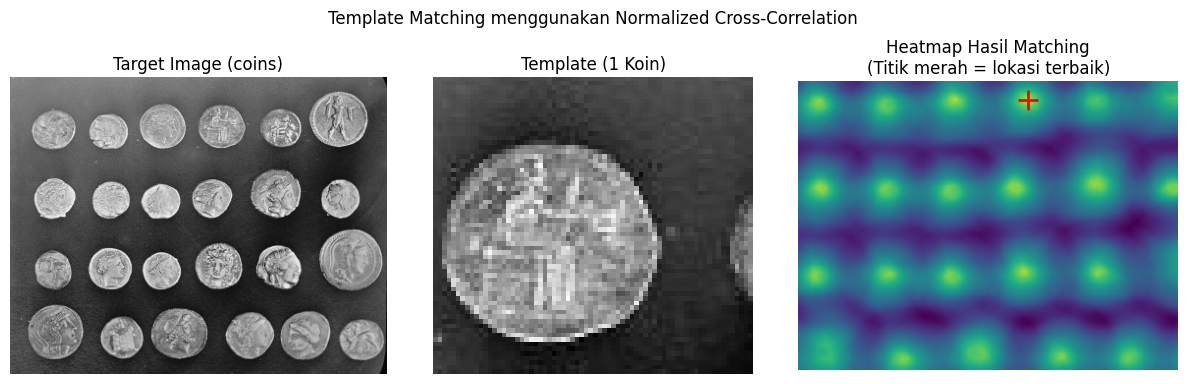

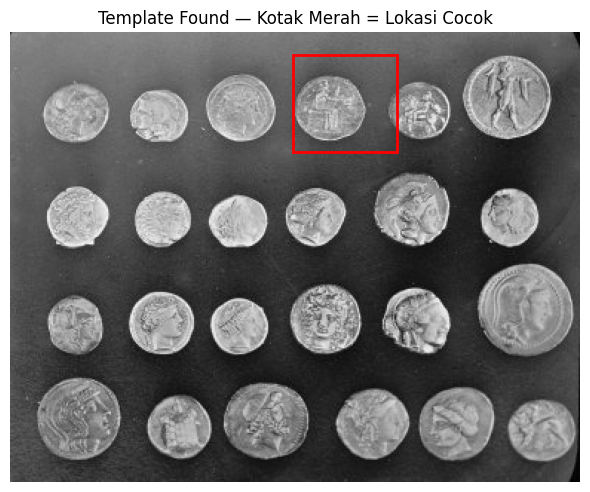

Template ditemukan di koordinat (x, y): (190, 15)
Skor NCC tertinggi                    : 1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan ambil template
image    = data.coins()
template = image[15:80, 190:260]  # Salah satu koin sebagai template

# 2. Lakukan template matching (Normalized Cross-Correlation)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij       = np.unravel_index(np.argmax(result), result.shape)
x, y     = ij[::-1]  # Koordinat (x, y) sudut kiri atas template yang cocok

# 4. Visualisasi: 3 panel (target, template, heatmap)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image (coins)')
ax[0].axis('off')

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template (1 Koin)')
ax[1].axis('off')

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Heatmap Hasil Matching\n(Titik merah = lokasi terbaik)')
ax[2].plot(x, y, 'r+', markersize=15, markeredgewidth=2)
ax[2].axis('off')

plt.suptitle('Template Matching menggunakan Normalized Cross-Correlation', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# 5. Visualisasi terpisah: kotak merah di citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found — Kotak Merah = Lokasi Cocok')
ax_main.axis('off')

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
plt.tight_layout()
plt.show()

print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")
print(f"Skor NCC tertinggi                    : {result.max():.4f}")

## Kesimpulan Praktikum 4

Dari hasil praktikum ini dapat disimpulkan:

1. **Template Matching berhasil** menemukan lokasi koin yang dijadikan template
   pada citra `coins`. Kotak merah tepat mengelilingi koin yang sesuai, dan
   skor NCC tertinggi mendekati **1.0** — menandakan kecocokan yang sangat tinggi.

2. **Heatmap hasil matching** menunjukkan area paling terang (nilai NCC tertinggi)
   tepat berada di lokasi koin template berada dalam citra asli. Area terang lain
   menunjukkan posisi koin-koin lain yang bentuknya mirip dengan template.

3. **Kelebihan Template Matching:**
   - Sederhana dan mudah diimplementasikan
   - Tidak memerlukan proses training/pelatihan model
   - Efektif untuk mencari objek yang identik atau sangat mirip

4. **Keterbatasan Template Matching Standar:**
   - **Tidak invariant terhadap rotasi** — jika template dirotasi, skor NCC
     akan turun drastis dan template tidak akan ditemukan
   - **Tidak invariant terhadap perubahan skala** — template yang diperbesar
     atau diperkecil tidak akan cocok dengan baik
   - **Sensitif terhadap perubahan pencahayaan** — meski NCC lebih robust
     dari SSD, perubahan pencahayaan besar tetap mengurangi akurasi
   - Untuk kasus yang memerlukan invariansi rotasi/skala, diperlukan metode
     lebih canggih seperti feature-based matching (SIFT, ORB, dll.)

# Praktikum 5: Simulasi Content-Based Image Retrieval (CBIR) Sederhana

## Tujuan
Praktikum ini mensimulasikan sistem **CBIR (Content-Based Image Retrieval)** sederhana,
yaitu sistem pencarian citra yang mencari gambar paling mirip dengan citra query
berdasarkan **konten visual** (bukan nama file atau metadata).

## Konsep Utama
- **Database Citra:** Kumpulan citra yang akan dicari
- **Query Image:** Citra yang dijadikan acuan pencarian
- **Fitur Visual:** Representasi ringkas dari citra — di sini menggunakan
  **histogram warna RGB** (48 dimensi: 16 bin × 3 channel)
- **Ranking:** Citra diurutkan dari yang paling mirip (jarak cosine terkecil)
  ke yang paling tidak mirip

## Alur Kerja CBIR

Memproses database citra...
  ✔ astronaut diproses.
  ✔ camera diproses.
  ✔ coffee diproses.
  ✔ coins diproses.
  ✔ chelsea diproses.

Hasil Retrieval untuk Query 'chelsea':
Rank   Nama         Cosine Distance
-----------------------------------
  1     chelsea      0.0000
  2     coins        0.2879
  3     coffee       0.3593
  4     astronaut    0.4612
  5     camera       0.6020


C:\Users\LATIFA\AppData\Local\Temp\ipykernel_21944\2780824096.py:83: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])
e:\SEMESTER 6\Pengolahan Citra\Weekly Task\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


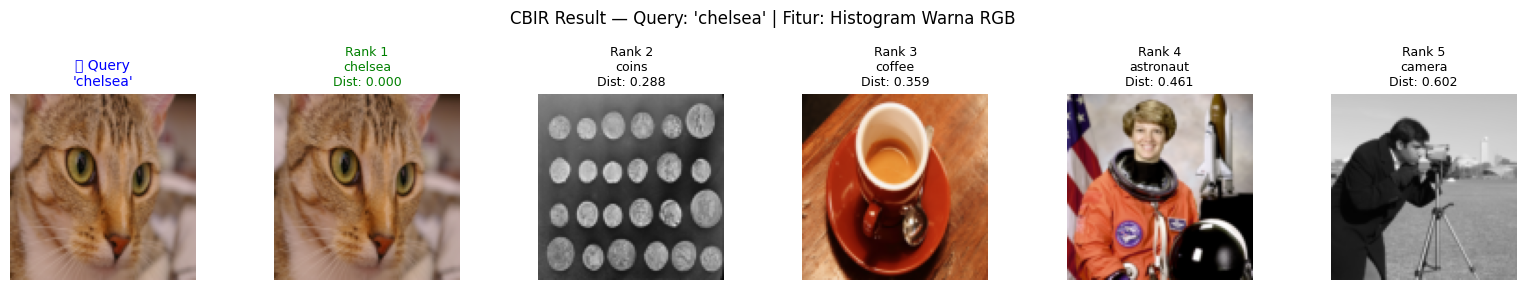

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float or image.max() <= 1.0:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)
    return hist_combined

# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists  = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:               # Grayscale → RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"  ✔ {name} diproses.")
    except Exception as e:
        print(f"  ✘ Error memproses {name}: {e}")

# 2. Pilih query image
query_image_name = "chelsea"
query_index      = image_db_names.index(query_image_name)
query_image      = database_images[query_index]
query_hist       = database_hists[query_index]

# 3. Hitung cosine distance antara query dan semua citra di database
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Urutkan berdasarkan jarak terkecil (paling mirip)
sorted_indices = np.argsort(distances)

# 5. Tampilkan hasil retrieval
num_results = len(database_images)
fig, axes   = plt.subplots(1, num_results + 1, figsize=(16, 3))

# Query
axes[0].imshow(query_image)
axes[0].set_title(f"🔍 Query\n'{query_image_name}'", fontsize=10, color='blue')
axes[0].axis('off')

# Hasil terurut
print(f"\nHasil Retrieval untuk Query '{query_image_name}':")
print(f"{'Rank':<6} {'Nama':<12} {'Cosine Distance'}")
print("-" * 35)
for i, idx in enumerate(sorted_indices):
    rank = i + 1
    ax   = axes[rank]
    ax.imshow(database_images[idx])
    label_color = 'green' if idx == query_index else 'black'
    ax.set_title(
        f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}",
        fontsize=9, color=label_color
    )
    ax.axis('off')
    print(f"  {rank:<5} {image_db_names[idx]:<12} {distances[idx]:.4f}")

plt.suptitle(
    f"CBIR Result — Query: '{query_image_name}' | Fitur: Histogram Warna RGB",
    fontsize=12
)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

## Kesimpulan Praktikum 5

Dari hasil praktikum ini dapat disimpulkan:

1. **Sistem CBIR berhasil diimplementasikan** — citra query `chelsea` (kucing)
   muncul di **Rank 1** dengan jarak cosine = 0.000 karena dibandingkan dengan
   dirinya sendiri dalam database.

2. **Ranking berdasarkan histogram warna** menunjukkan bahwa citra dengan
   distribusi warna paling mirip dengan kucing (dominan oranye, putih, coklat)
   akan muncul di peringkat teratas.

3. **Keterbatasan histogram warna sebagai fitur CBIR:**
   - Tidak mempertimbangkan **posisi spasial** piksel — dua citra dengan
     komposisi warna sama tapi susunan berbeda dianggap mirip
   - Tidak menangkap informasi **bentuk atau tekstur** objek
   - Pada database kecil ini, hasilnya mungkin kurang intuitif karena
     pilihan citra sangat beragam

4. **Untuk CBIR yang lebih baik** diperlukan fitur yang lebih kaya seperti:
   - Histogram + tekstur (Gabor filter, LBP)
   - Deep learning features (CNN embeddings)
   - Kombinasi fitur warna + bentuk + tekstur

## Kesimpulan Umum Jobsheet 05
Berbagai metode pengukuran kemiripan memiliki karakteristik yang berbeda:

| Metode | Keunggulan | Keterbatasan |
|---|---|---|
| Euclidean / Manhattan | Sederhana, cepat | Sensitif noise & pencahayaan |
| Cosine Similarity | Tidak terpengaruh magnitude | Abaikan posisi spasial |
| SSIM | Sesuai persepsi manusia | Lebih lambat, hanya piksel |
| Template Matching | Mudah, tanpa training | Tidak invariant rotasi/skala |
| CBIR (Histogram) | Efisien untuk warna | Abaikan bentuk & tekstur |

Pemilihan metode yang tepat selalu bergantung pada **kebutuhan aplikasi**
dan **karakteristik data citra** yang digunakan.